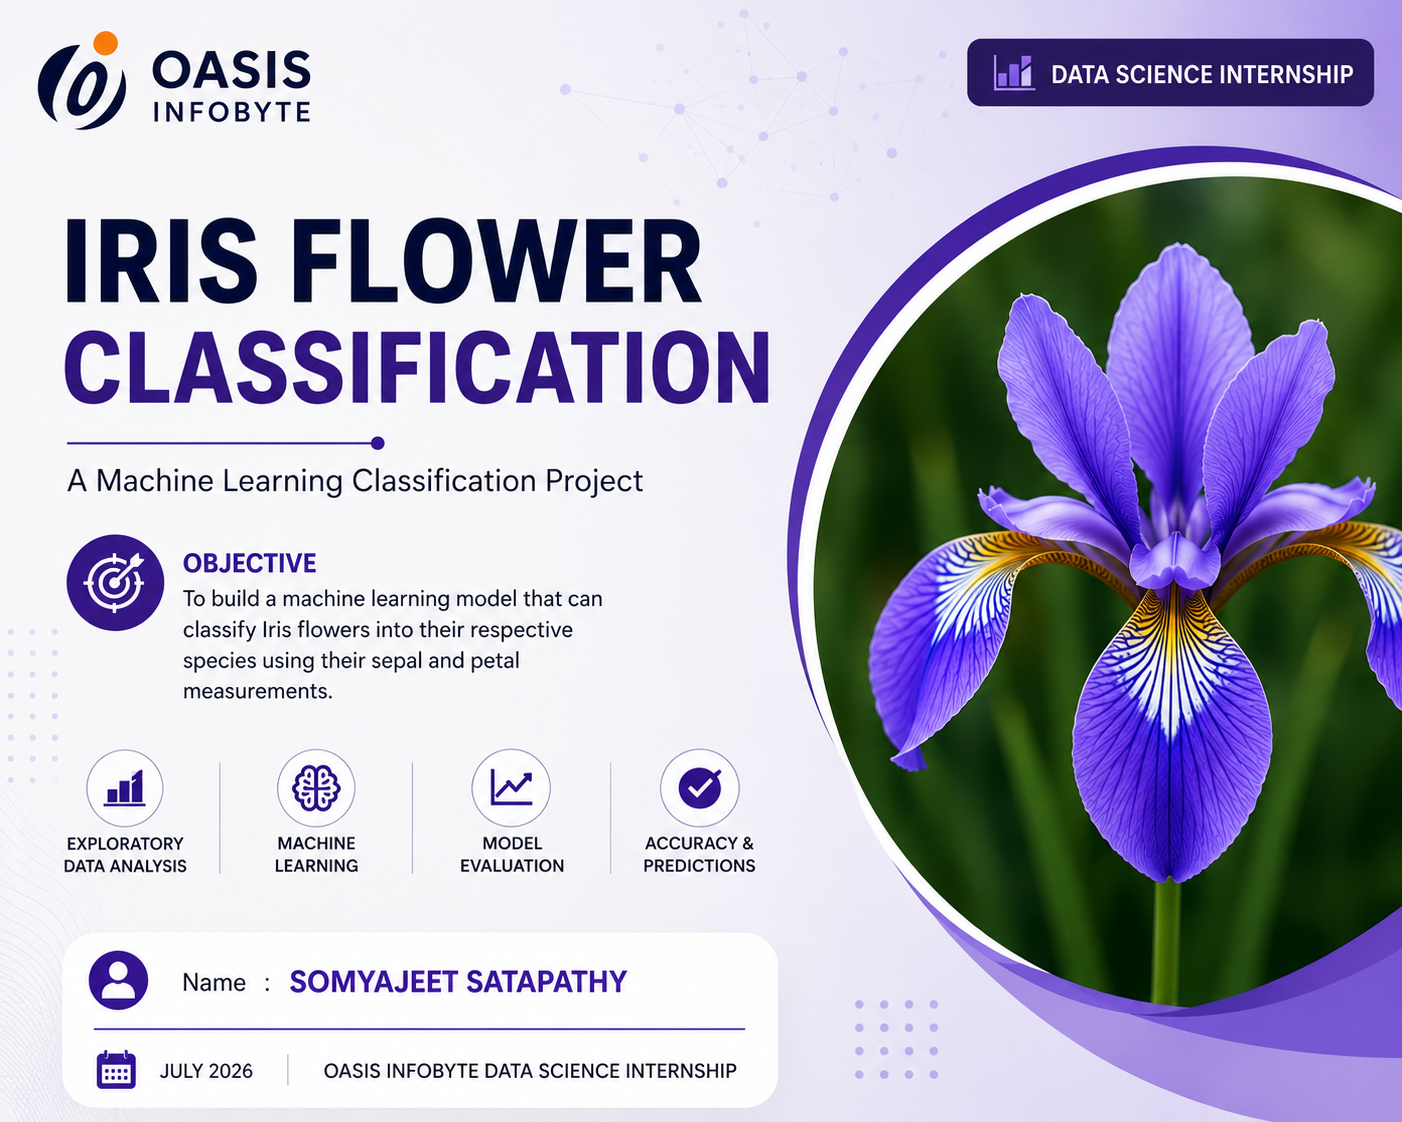

# **Iris Flower Classification**

> ### **By SOMYAJEET SATAPATHY**

> ### **Dataset : iris.csv**

## **Oasis Infobyte Data Science Internship**

This project focuses on classifying Iris flowers into different species using machine learning classification models.

## **Objective**

The main objective of this project is to build a machine learning model that can classify Iris flowers into their respective species using their sepal and petal measurements.

The project includes basic data exploration, visualization, model training and evaluation.

In [ ]:
# Importing the libraries needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_iris

# Loading the Iris dataset from scikit-learn
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='Species')

df = X.copy()
df['Species'] = y.map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Checking the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 5


In [ ]:
# Displaying the names of all columns
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

In [ ]:
# Viewing a few records from the dataset
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Checking the last few records
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [ ]:
# Checking the data types and overall structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# Checking whether the dataset contains missing values
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
Species,0


In [ ]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(1)

In [ ]:
# Getting the basic statistical summary of the numerical features
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Checking how many records belong to each species
df['Species'].value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


In [ ]:
# Checking the average measurements for each species
df.groupby('Species').mean(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


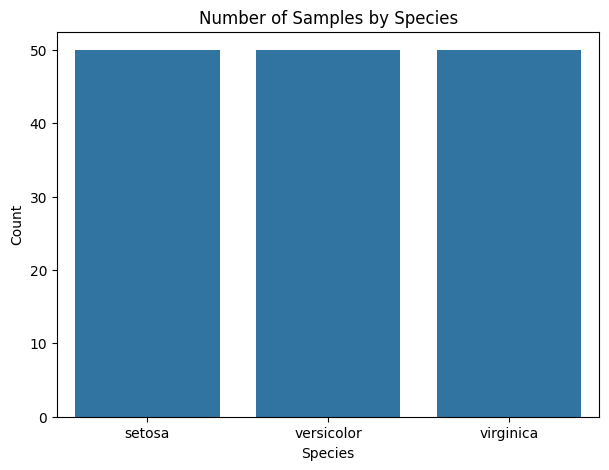

In [ ]:
# Visualizing the number of samples for each species
plt.figure(figsize=(7, 5))
sns.countplot(x='Species', data=df)
plt.title('Number of Samples by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

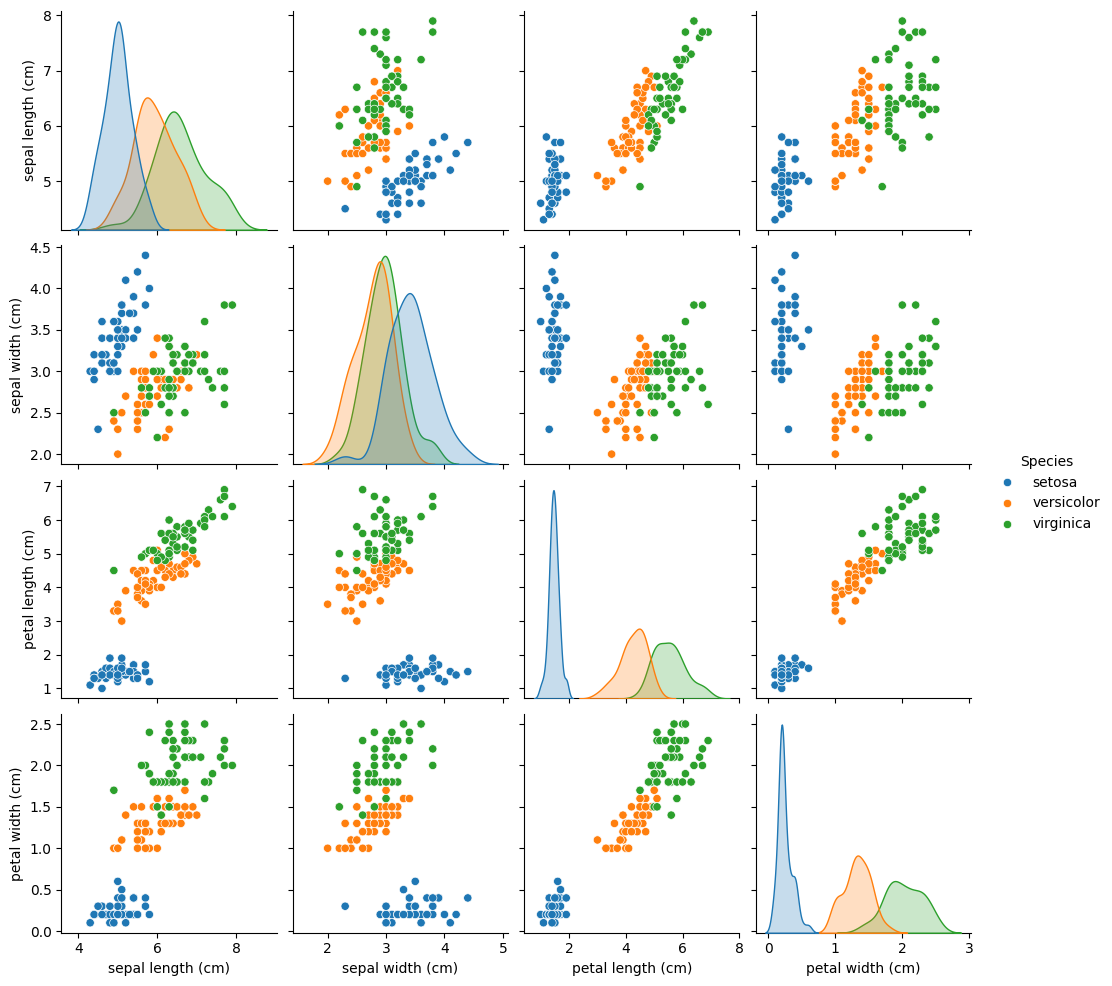

In [ ]:
# Comparing all features across the three species
sns.pairplot(df, hue='Species')
plt.show()

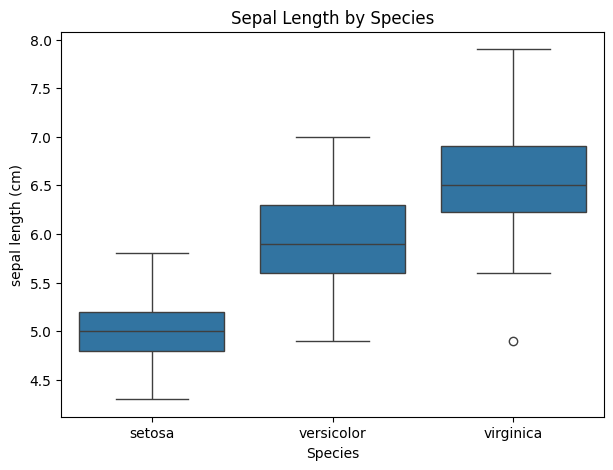

In [ ]:
# Comparing sepal length across the three species
plt.figure(figsize=(7, 5))
sns.boxplot(x='Species', y='sepal length (cm)', data=df)
plt.title('Sepal Length by Species')
plt.show()

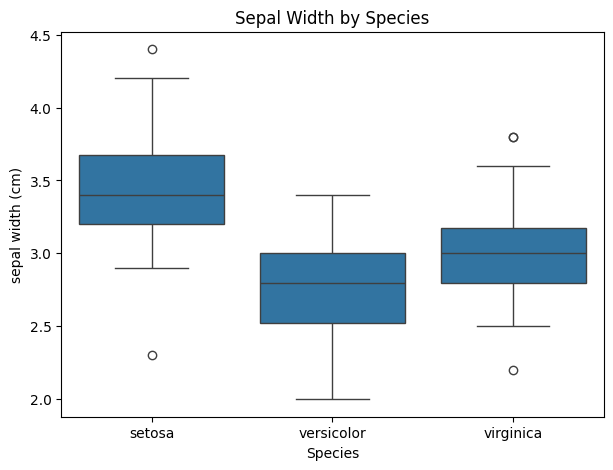

In [ ]:
# Comparing sepal width across the three species
plt.figure(figsize=(7, 5))
sns.boxplot(x='Species', y='sepal width (cm)', data=df)
plt.title('Sepal Width by Species')
plt.show()

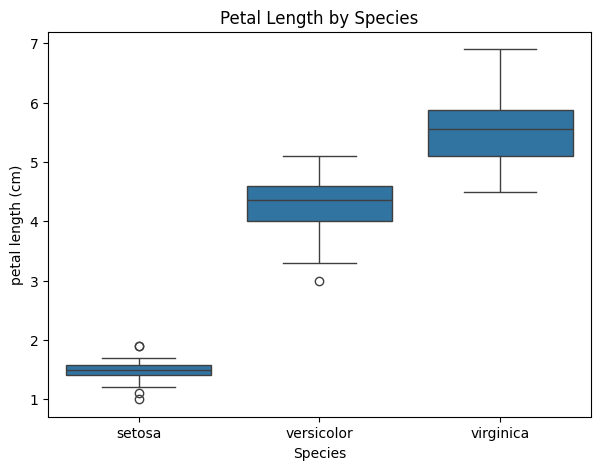

In [ ]:
# Comparing petal length across the three species
plt.figure(figsize=(7, 5))
sns.boxplot(x='Species', y='petal length (cm)', data=df)
plt.title('Petal Length by Species')
plt.show()

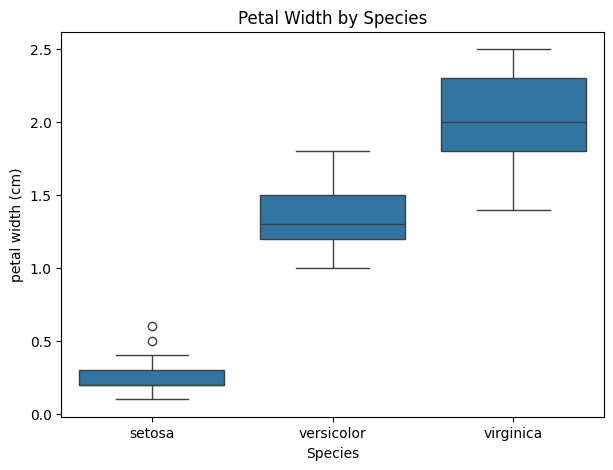

In [ ]:
# Comparing petal width across the three species
plt.figure(figsize=(7, 5))
sns.boxplot(x='Species', y='petal width (cm)', data=df)
plt.title('Petal Width by Species')
plt.show()

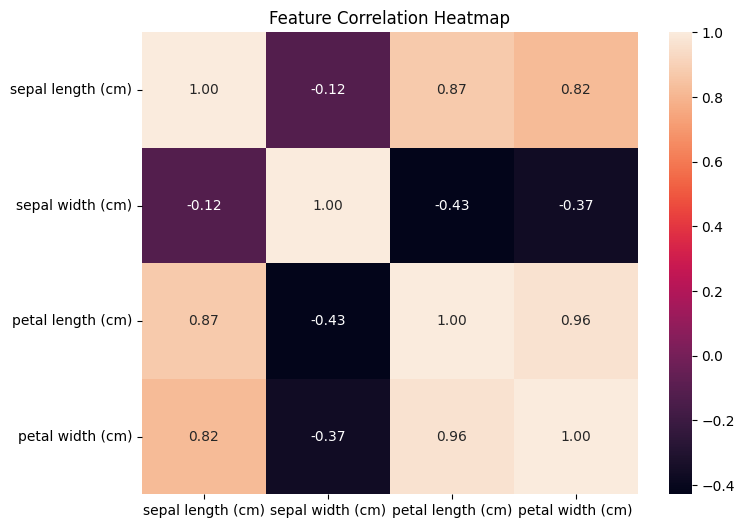

In [ ]:
# Checking the relationship between the numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Comparing the average value of each feature for every species
feature_means = df.groupby('Species')[iris.feature_names].mean()
feature_means

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


## Feature Selection Discussion

From the pairplot and box plots, petal length and petal width show the clearest difference between the three Iris species.

The three species overlap more when the sepal measurements are considered. In comparison, the petal measurements form more clearly separated groups.

Therefore, petal length and petal width appear to be the most discriminative features for identifying the Iris species.

In [ ]:
# Separating the input features from the target variable
X = df[iris.feature_names]
y = df['Species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: Species, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [ ]:
from sklearn.linear_model import LogisticRegression

# Training the Logistic Regression model
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Training the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Making predictions using both trained models
log_pred = log_model.predict(X_test)
tree_pred = tree_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

# Calculating the accuracy of both models
log_accuracy = accuracy_score(y_test, log_pred)
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", tree_accuracy)

Logistic Regression Accuracy: 0.9666666666666667
Decision Tree Accuracy: 0.9333333333333333


In [ ]:
from sklearn.metrics import confusion_matrix

# Creating confusion matrices for both models
log_cm = confusion_matrix(y_test, log_pred)
tree_cm = confusion_matrix(y_test, tree_pred)

print("Logistic Regression Confusion Matrix:")
print(log_cm)

print("\nDecision Tree Confusion Matrix:")
print(tree_cm)

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


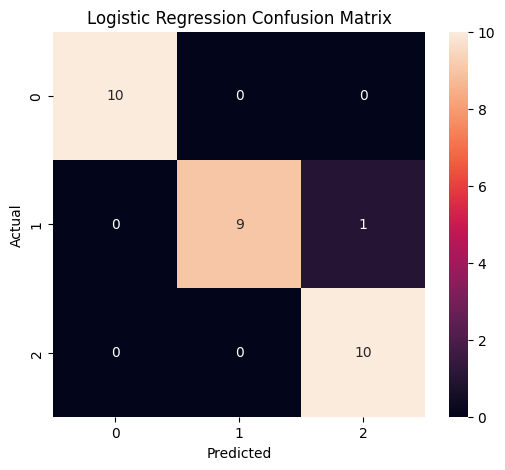

In [ ]:
# Visualizing the Logistic Regression confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(log_cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

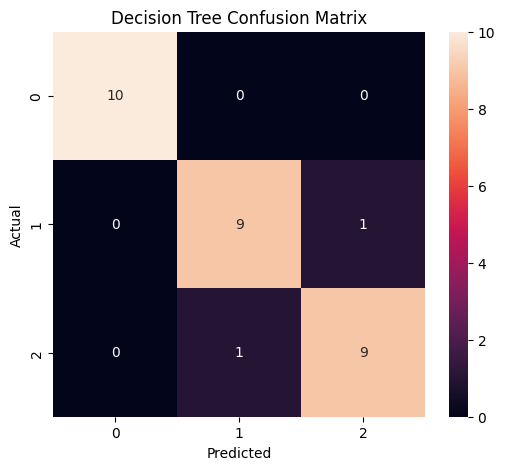

In [ ]:
# Visualizing the Decision Tree confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(tree_cm, annot=True, fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generating detailed performance reports for both models
print("Logistic Regression Classification Report")
print(classification_report(y_test, log_pred))

print("\nDecision Tree Classification Report")
print(classification_report(y_test, tree_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Decision Tree Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# Comparing the accuracy achieved by both models
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [log_accuracy, tree_accuracy]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.966667
1,Decision Tree,0.933333


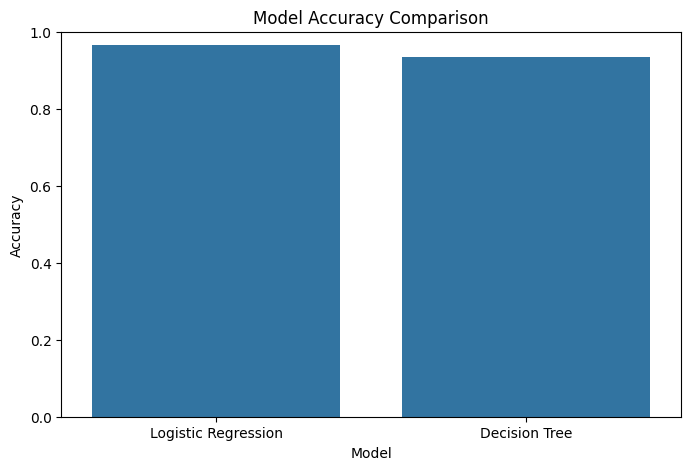

In [ ]:
# Visualizing the accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=model_results)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
# Finding the model with the highest accuracy
best_model = model_results.loc[model_results['Accuracy'].idxmax()]

print("Best Model:", best_model['Model'])
print("Accuracy:", best_model['Accuracy'])

Best Model: Logistic Regression
Accuracy: 0.9666666666666667


## Conclusion

The Iris dataset was explored using basic statistical analysis and different visualizations. The dataset did not contain missing values, and the three species had an equal number of samples.

The pairplot and box plots showed that petal length and petal width were the most useful features for separating the three Iris species.

Two classification models were trained: Logistic Regression and Decision Tree. Both models performed well on the test data.

Logistic Regression achieved an accuracy of 96.67%, while Decision Tree achieved an accuracy of 93.33%. Based on the test accuracy and classification results, Logistic Regression was the better-performing model for this dataset.

Overall, the results show that the Iris species can be classified effectively using simple machine learning classification techniques.

# **THANK YOU**